<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_12_NLMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules, including `google.colab.drive` for accessing the required assets for the notebook from Google Drive

In [ ]:
from skimage.io import imread          # pyright: ignore[reportMissingImports]
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive         # pyright: ignore[reportMissingImports]

In [42]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


Load the image and rescale it in $[0,1]$

In [ ]:
img = imread(f'{ROOT_FOLDER}/cameraman.png') / 255.0
img = img[50:200, 50:200]
imsz = img.shape

p = 7       # patch size
M = p ** 2  # no. of elements in the patch
H = 25      # radius of the search neighborhood

Corrupt the image with white gaussian noise

In [60]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(0, sigma_noise, size=imsz)

Compute the PSNR of the noisy input

In [61]:
psnr_noisy = 10*np.log(1/np.mean(np.square(img - noisy_img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 50.95')

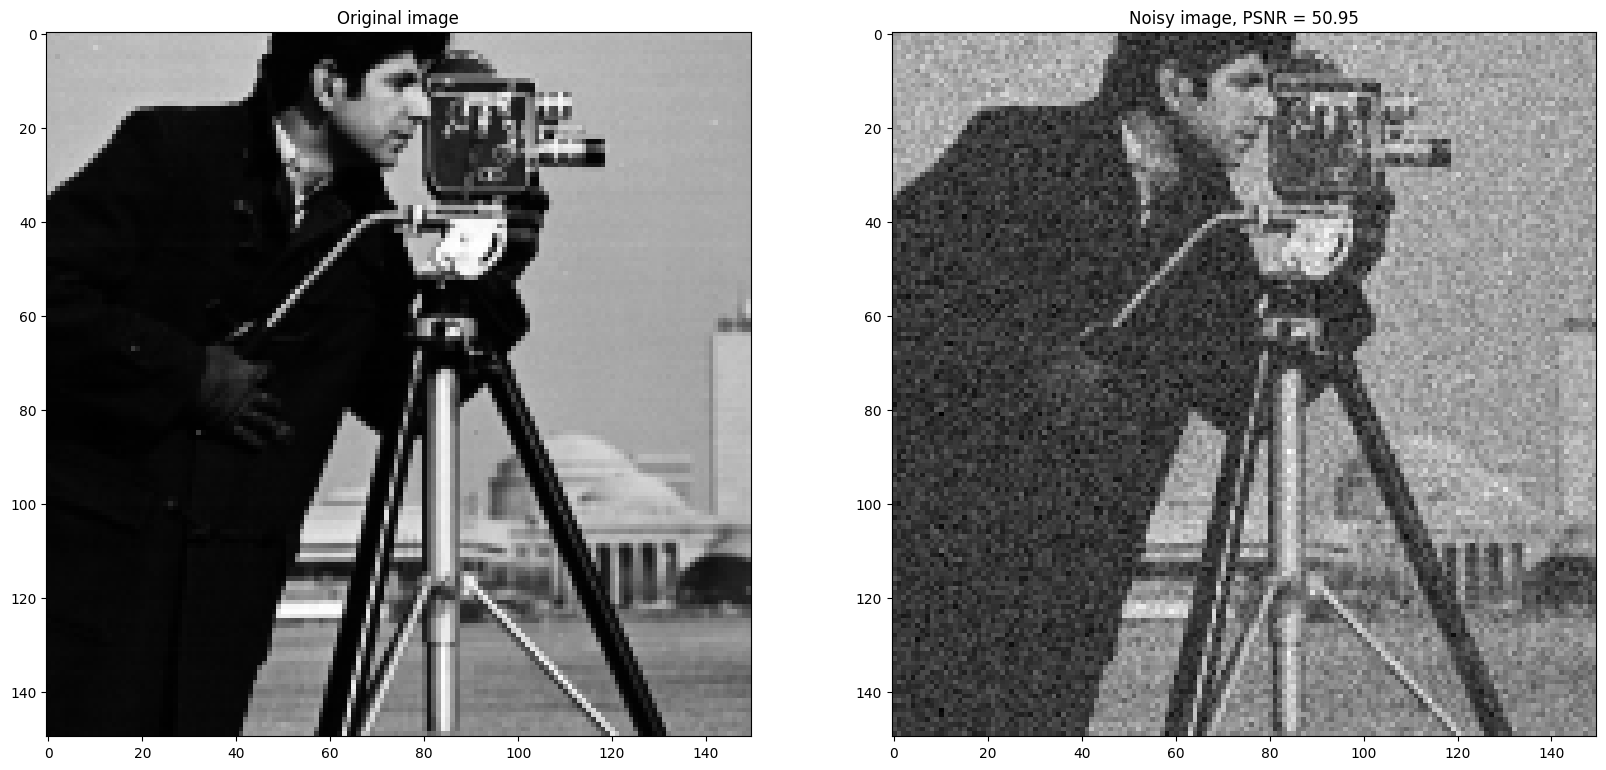

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [63]:
# Initialize the estimated image
img_hat = np.zeros_like(noisy_img)

# Pad the noisy image
k = p // 2
img_pad = np.pad(noisy_img, k, mode='symmetric')

Main loop

In [ ]:
for r in range(0, imsz[0]):
    for c in range(0, imsz[1]):
        # Extrach the patch from img_pad whose center has the location (r, c) in
        # noisy_img
        s = img_pad[r:r + 2*k + 1, c:c + 2*k + 1].flatten()

        # Initialize the pixel estimate and the total weights
        pixel_hat = 0
        weight = np.zeros((2*H + 1, 2*H + 1))

        # Extract all the patches in the search neighborhood
        for i in range(-H, H+1):
            for j in range(-H, H+1):
               # Extract the patch
                r_noisy = r + i
                c_noisy = c + j
                if (r_noisy >= 0 and c_noisy >= 0 and r_noisy + 2*k + 1 < imsz[0] - 1 and c_noisy + 2*k + 1 < imsz[1] - 1):
                    z = img_pad[r_noisy:r_noisy + 2*k + 1,
                                c_noisy:c_noisy + 2*k + 1].flatten()

                    # Compute the distance with the reference patch
                    d = np.sum((s - z) ** 2)
                    # Update the weight and the pixel estimate
                    weight[i + H, j +
                           H] = np.exp(-d / (M * (sigma_noise ** 2)))
                    pixel_hat += weight[i + H, j + H] * \
                        img_pad[r_noisy + k, c_noisy + k]

        img_hat[r, c] = pixel_hat / np.sum(weight)

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image\nPSNR = 27.18')

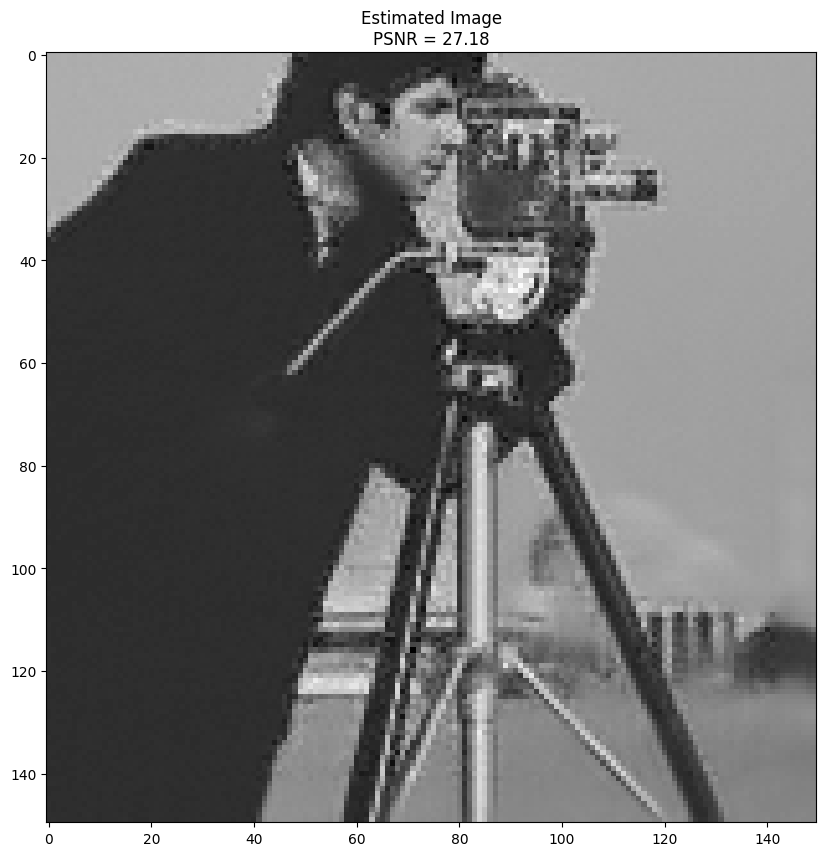

In [58]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img - img_hat)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image\nPSNR = {psnr_hat:.2f}')